# Credit Card Fraud Detection
### Capstone Project — IoT Academy

---

## Project Overview

Every day, millions of credit card transactions happen around the world.  
A small number of these transactions are **fraudulent** — meaning someone is using a card without the owner's permission.

Our goal is to **build a Machine Learning and Deep Learning model** that can automatically detect these fraudulent transactions.

### Dataset
We are using the **Credit Card Fraud Detection dataset** from Kaggle.  
It contains transactions made by European cardholders in September 2013.

- **Total transactions:** 284,807  
- **Fraud cases:** 492 (only 0.17% of all transactions!)  
- **Features:** 30 columns — 28 anonymous PCA features (V1–V28), Amount, and Time

### Our Plan
1. Load and explore the data
2. Prepare the data for training
3. Train ML models (Logistic Regression, Decision Tree, Random Forest, XGBoost)
4. Train a Deep Learning model (Artificial Neural Network)
5. Compare all models and pick the best one

---
## Step 1: Import Libraries

First, we bring in all the tools (libraries) we need.

In [1]:
# Basic data handling
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay
)

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries loaded successfully!")

All libraries loaded successfully!


---
## Step 2: Load the Dataset

Let's load the CSV file and take a first look at the data.

In [2]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nNumber of rows (transactions): {df.shape[0]:,}")
print(f"Number of columns (features): {df.shape[1]}")

# Show first 5 rows
df.head()

Dataset shape: (284807, 31)

Number of rows (transactions): 284,807
Number of columns (features): 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Basic information about the dataset
print("Dataset Info:")
print("-" * 40)
df.info()

print("\nMissing values in each column:")
print(df.isnull().sum())
print("\nNo missing values!")

Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float6

In [3]:
# Basic statistics
print("Summary Statistics (Amount and Time columns):")
df[['Time', 'Amount']].describe()

Summary Statistics (Amount and Time columns):


,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


---
## Step 3: Explore the Data (EDA)

Before building any model, we should **understand our data**.  
Let's look at the distribution of fraud vs. normal transactions.

Class Distribution:
  Normal transactions (Class=0): 284,315
  Fraud transactions  (Class=1): 492

  Fraud percentage: 0.17%

This is a highly IMBALANCED dataset — fraud is very rare!


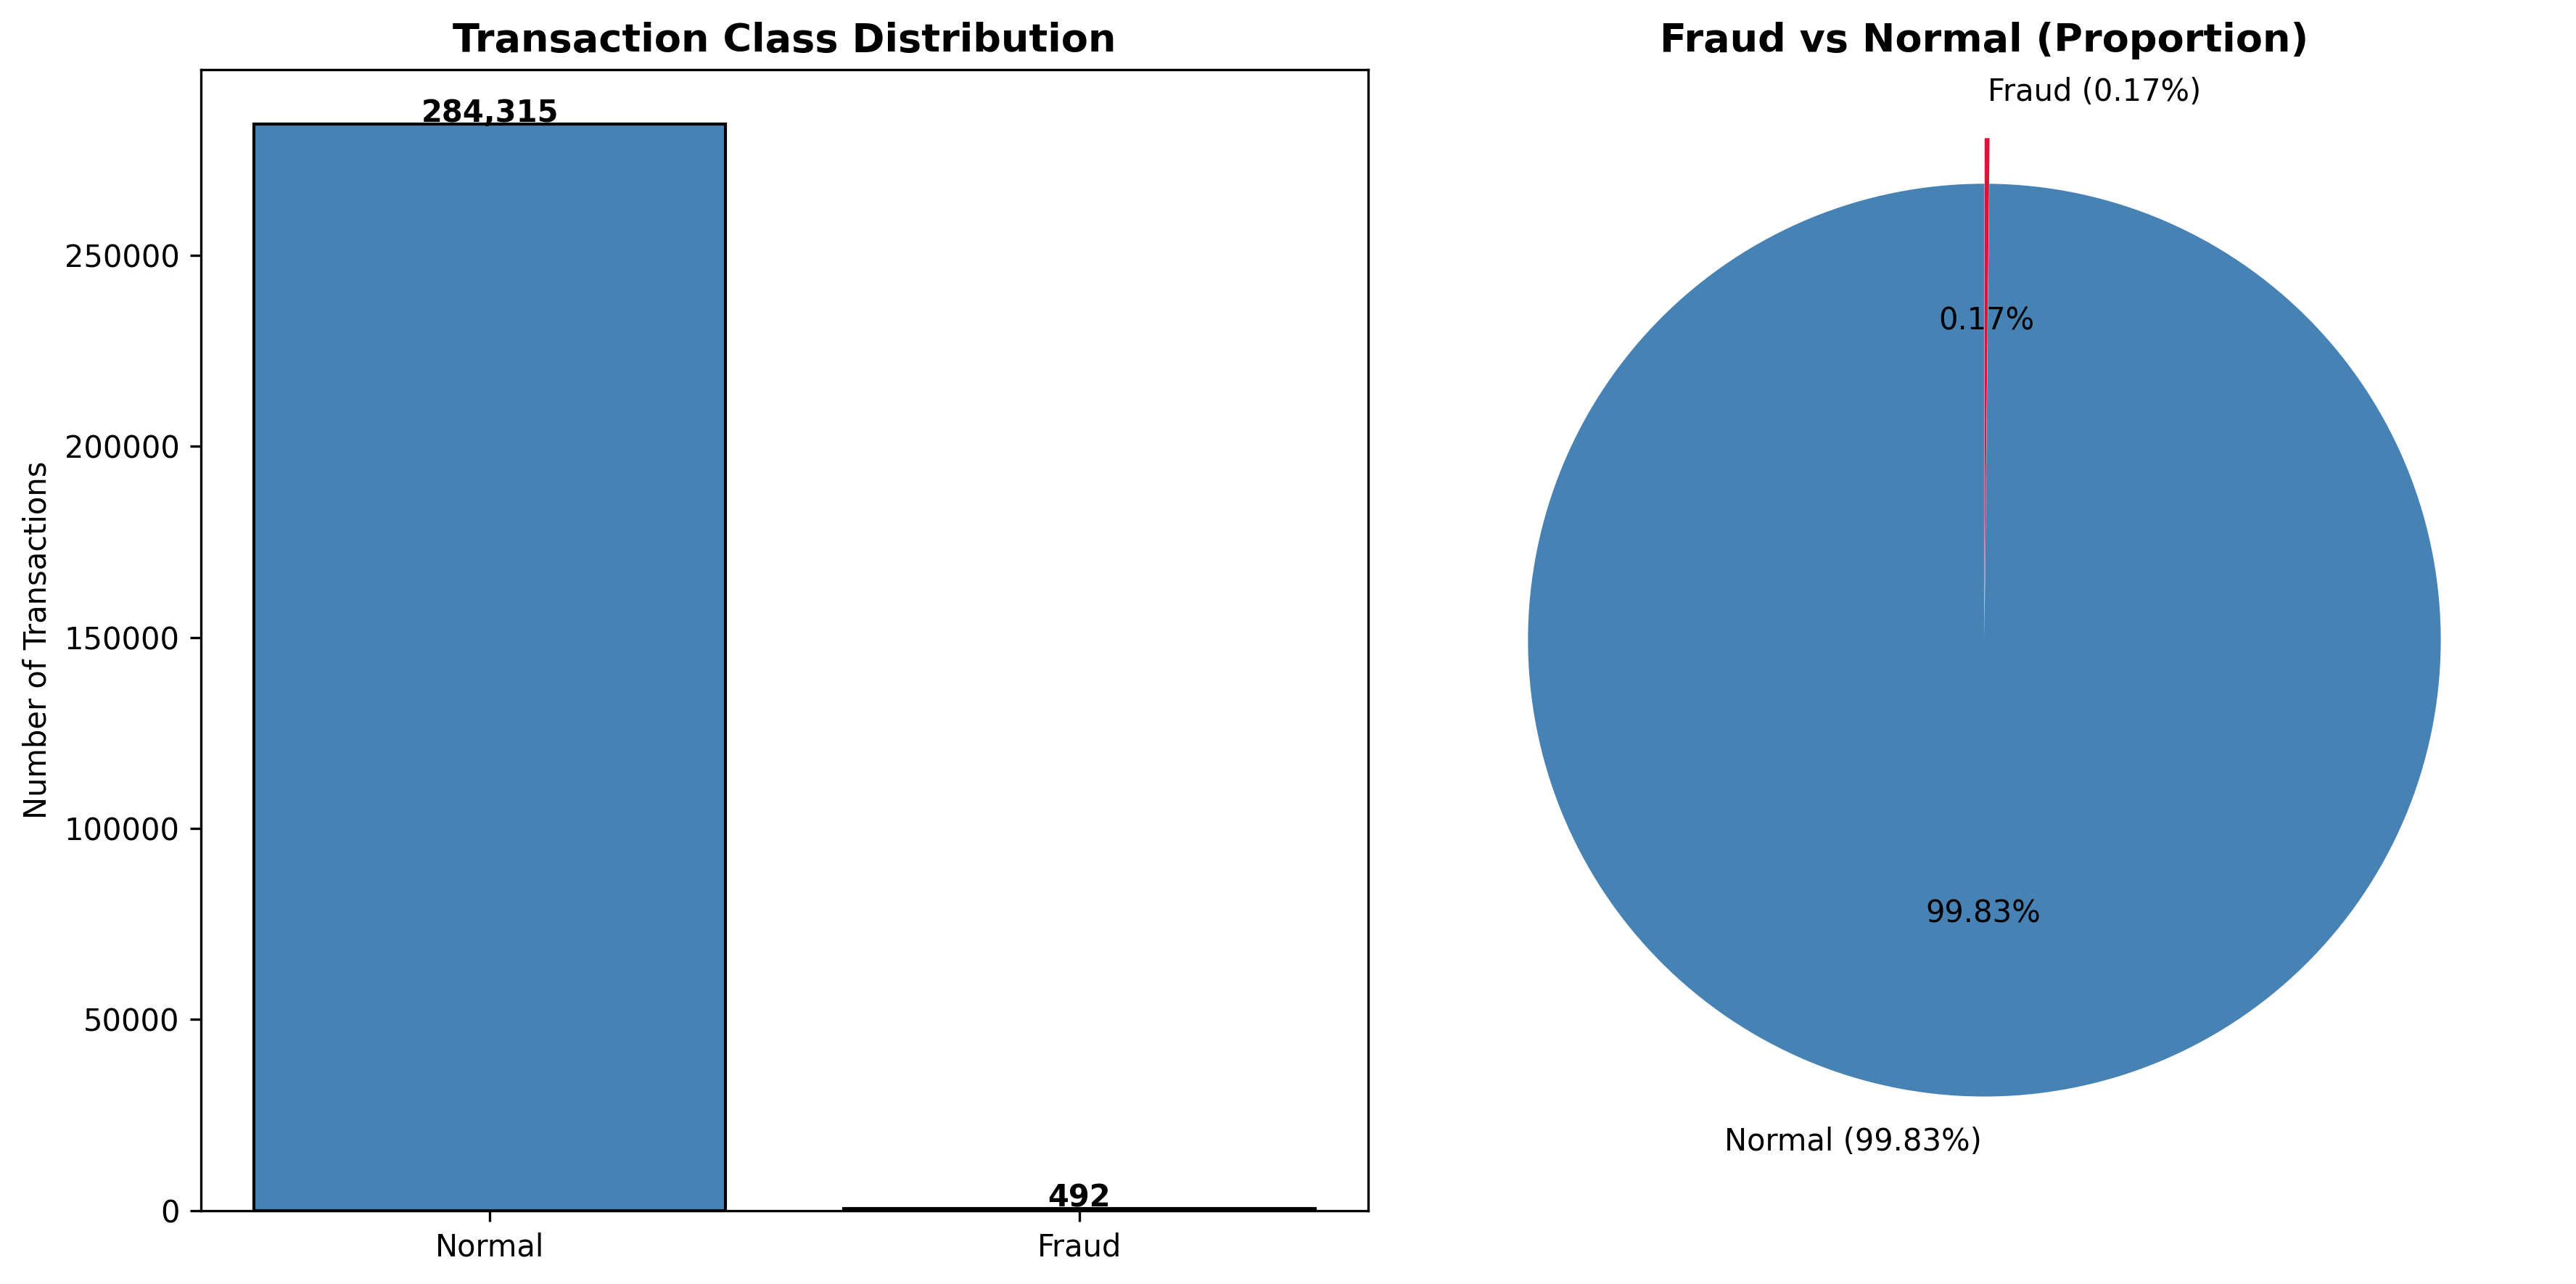

In [ ]:
# How many fraud vs normal transactions are there?
class_counts = df['Class'].value_counts()
print("Class Distribution:")
print(f"  Normal transactions (Class=0): {class_counts[0]:,}")
print(f"  Fraud transactions  (Class=1): {class_counts[1]:,}")
print(f"\n  Fraud percentage: {class_counts[1] / len(df) * 100:.2f}%")

# Plot the class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300)

# Bar chart
axes[0].bar(['Normal', 'Fraud'], class_counts.values, color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Transaction Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=['Normal (99.83%)', 'Fraud (0.17%)'],
    colors=['steelblue', 'crimson'],
    startangle=90,
    autopct='%1.2f%%',
    explode=(0, 0.1)
)
axes[1].set_title('Fraud vs Normal (Proportion)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Observation: The dataset is heavily imbalanced, with fraud making up only 0.17% of all transactions. This means the model must be careful not to overfit to the majority class.

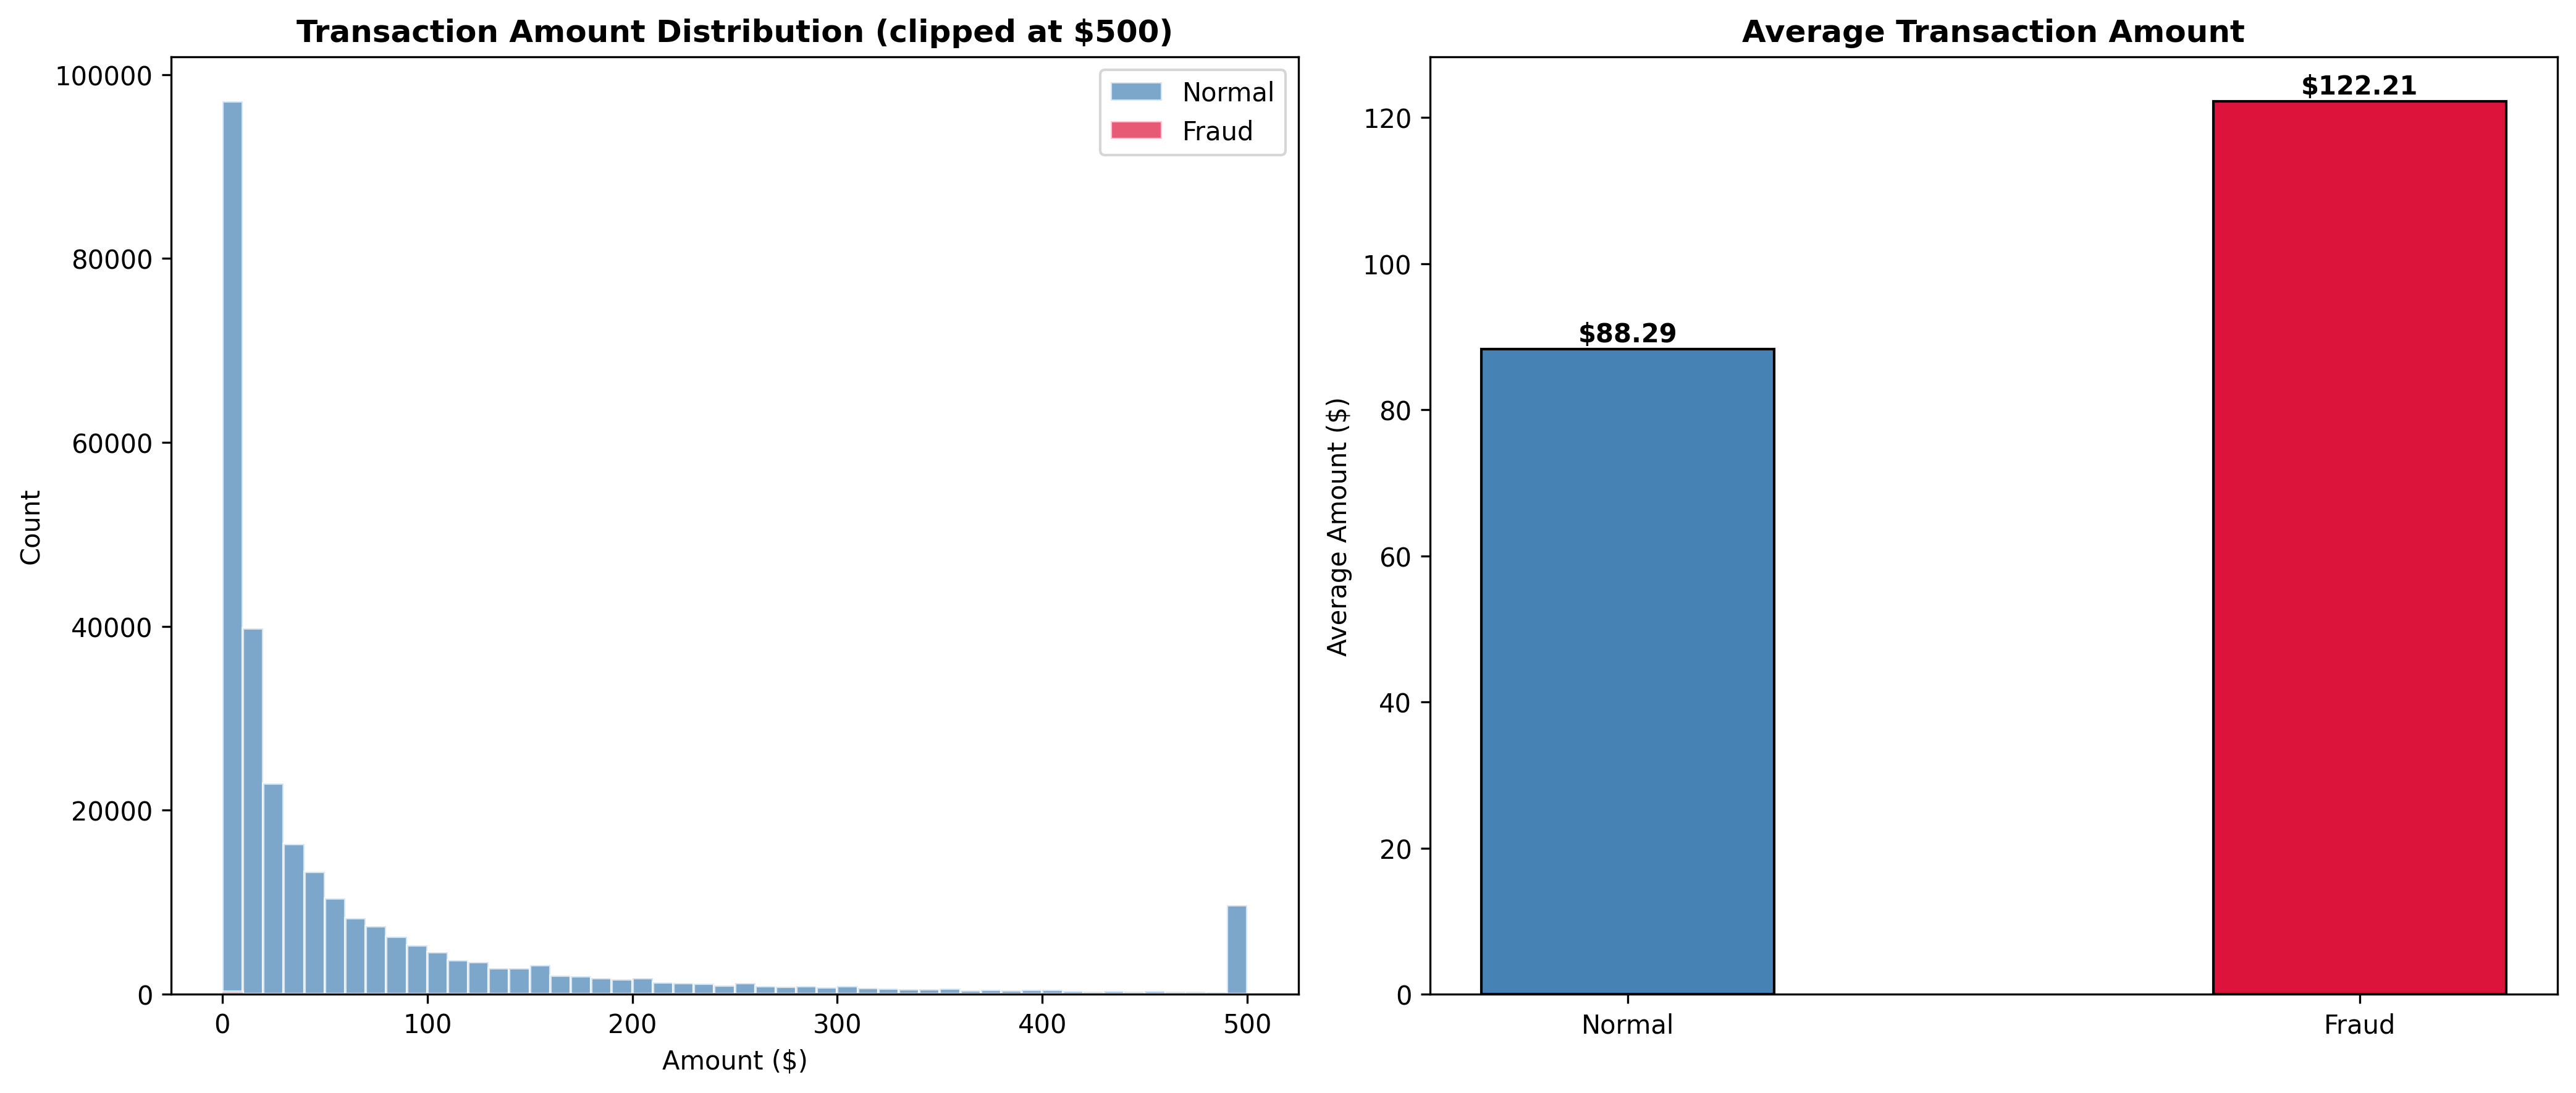

Average Normal transaction amount: $88.29
Average Fraud  transaction amount: $122.21


In [8]:
# Compare transaction amounts: Fraud vs Normal
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

# Amount distribution
normal_amounts  = df[df['Class'] == 0]['Amount']
fraud_amounts   = df[df['Class'] == 1]['Amount']

axes[0].hist(normal_amounts.clip(upper=500), bins=50, alpha=0.7, color='steelblue', label='Normal', edgecolor='white')
axes[0].hist(fraud_amounts.clip(upper=500), bins=50, alpha=0.7, color='crimson', label='Fraud', edgecolor='white')
axes[0].set_title('Transaction Amount Distribution (clipped at $500)', fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Average amounts
avg_data = {
    'Normal': normal_amounts.mean(),
    'Fraud': fraud_amounts.mean()
}
axes[1].bar(avg_data.keys(), avg_data.values(), color=['steelblue', 'crimson'], edgecolor='black', width=0.4)
axes[1].set_title('Average Transaction Amount', fontweight='bold')
axes[1].set_ylabel('Average Amount ($)')
for i, (k, v) in enumerate(avg_data.items()):
    axes[1].text(i, v + 1, f'${v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Average Normal transaction amount: ${normal_amounts.mean():.2f}")
print(f"Average Fraud  transaction amount: ${fraud_amounts.mean():.2f}")

Observation: Fraudulent transactions tend to have higher average amounts than normal ones, which suggests that transaction value may be a useful signal for detection. The distribution also shows that fraud is less common but often concentrated in larger-value transactions.

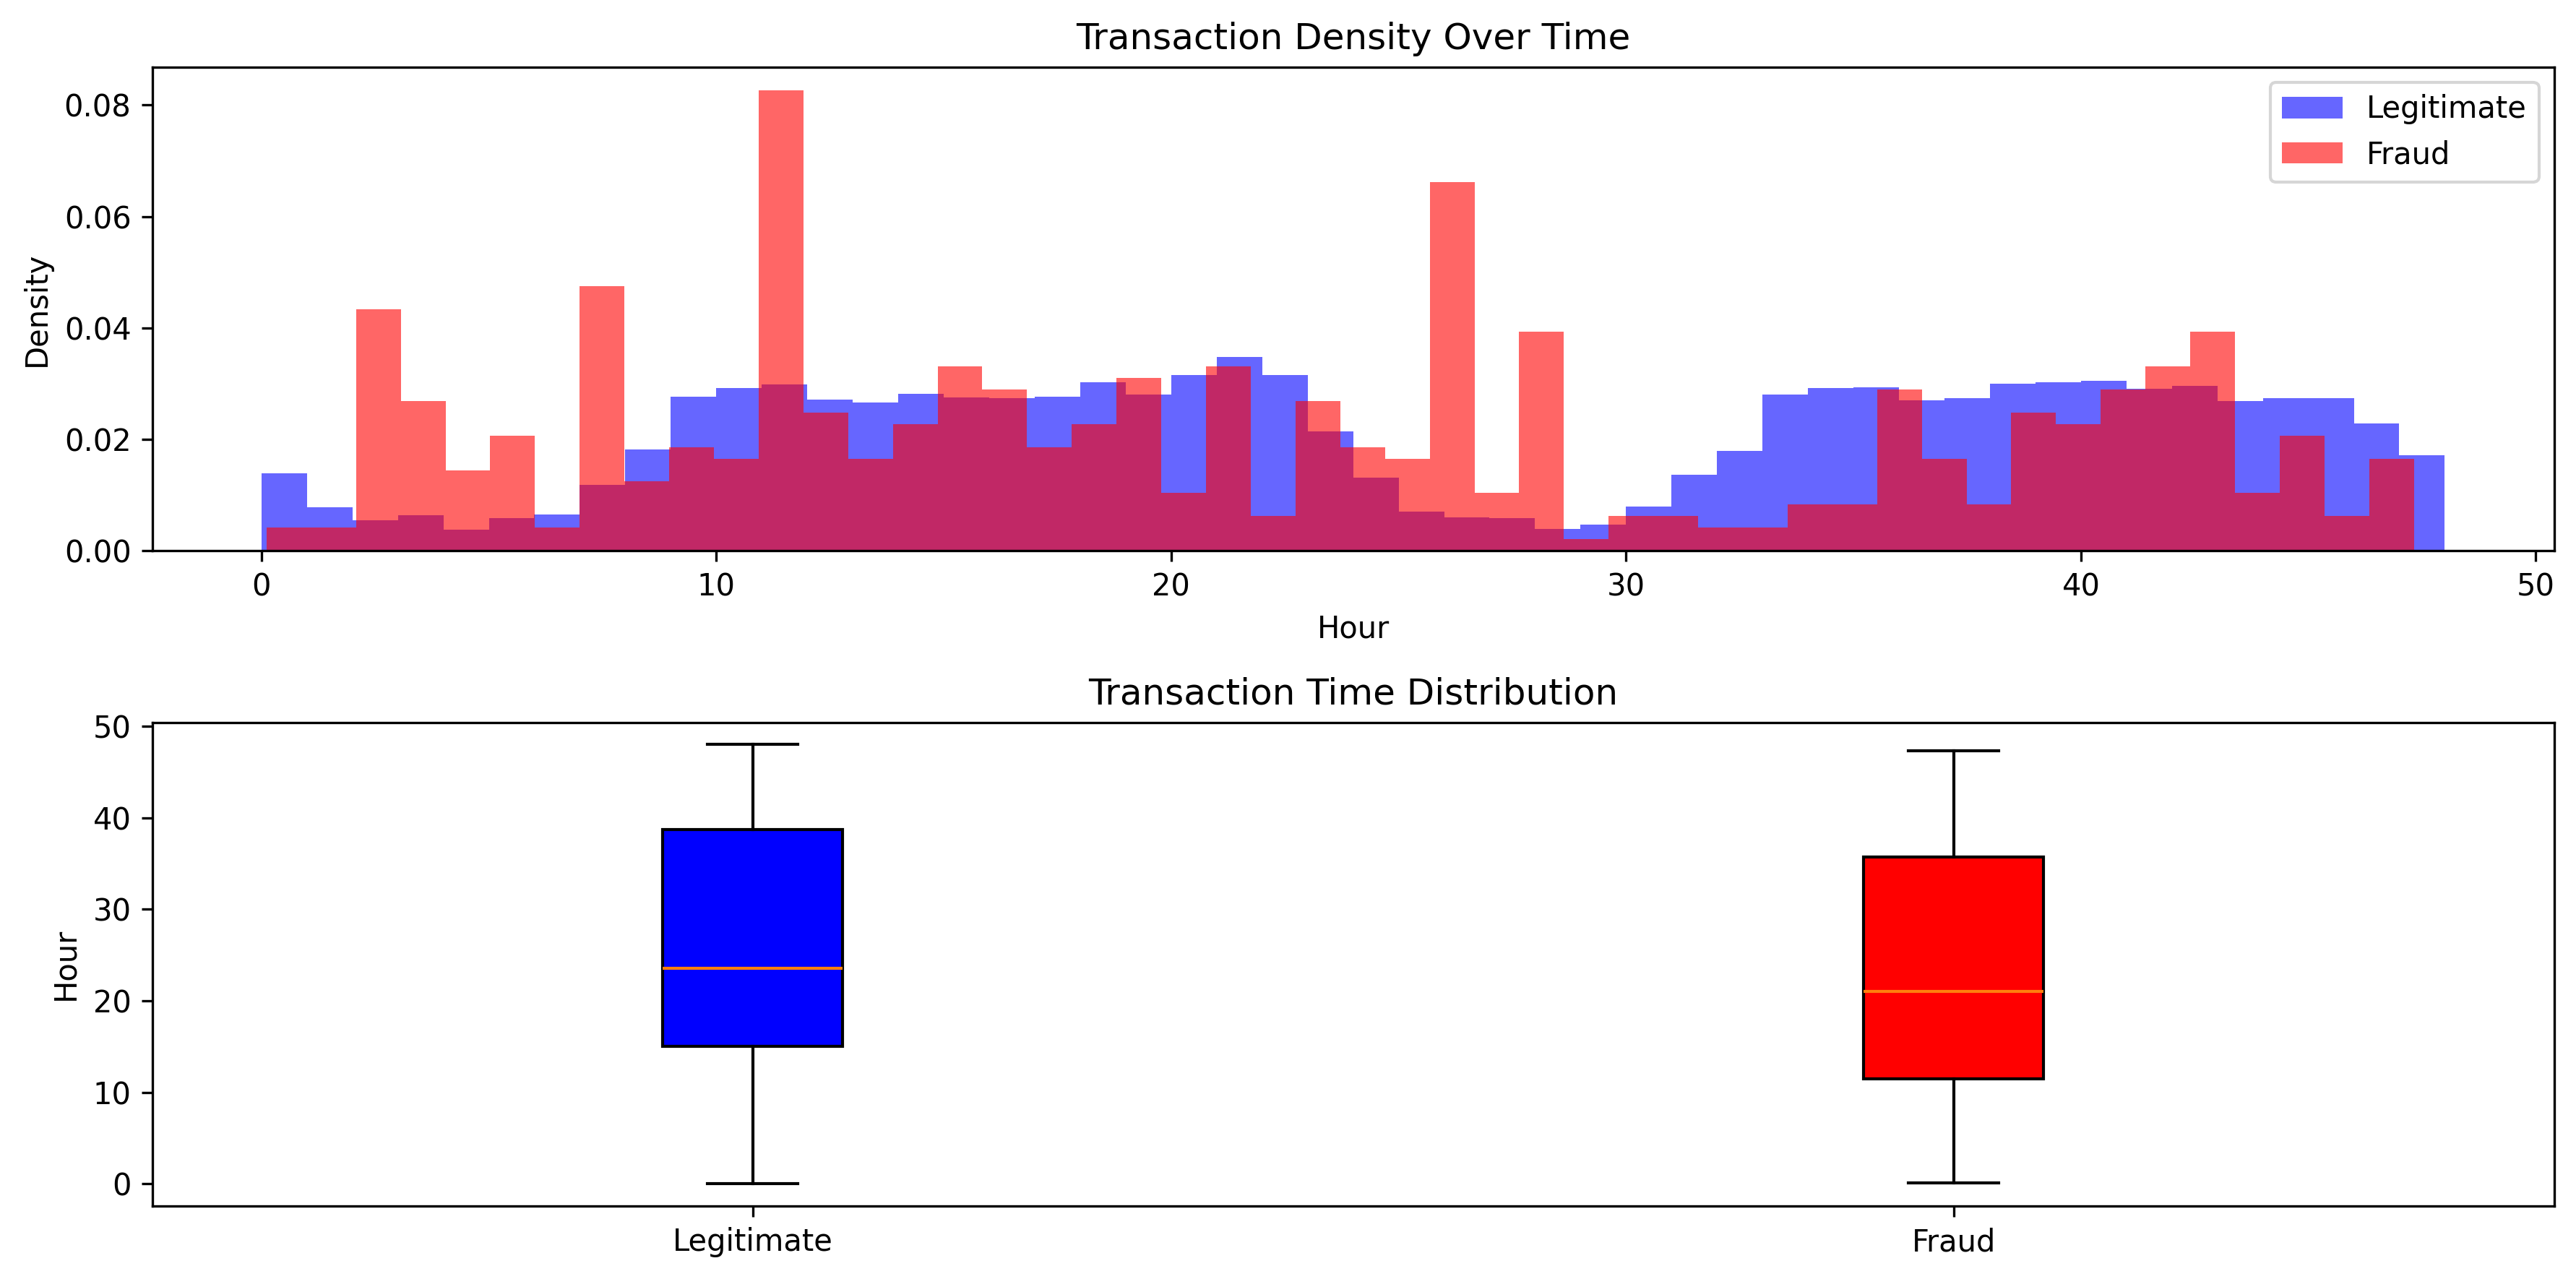

In [12]:
# Convert time to hours
df['Hour'] = df['Time'] / 3600

# Separate data
legit = df[df['Class'] == 0]['Hour']
fraud = df[df['Class'] == 1]['Hour']

plt.figure(figsize=(12, 6), dpi=300)

# Histogram 
plt.subplot(2, 1, 1)
plt.hist(legit, bins=48, alpha=0.6, color='blue', label='Legitimate', density=True)
plt.hist(fraud, bins=48, alpha=0.6, color='red', label='Fraud', density=True)

plt.title('Transaction Density Over Time')
plt.xlabel('Hour')
plt.ylabel('Density')
plt.legend()

# Boxplot 
plt.subplot(2, 1, 2)
bp = plt.boxplot([legit, fraud], labels=['Legitimate', 'Fraud'], patch_artist=True)

bp['boxes'][0].set_facecolor('blue')
bp['boxes'][1].set_facecolor('red')

plt.title('Transaction Time Distribution')
plt.ylabel('Hour')

plt.tight_layout()
plt.savefig('transaction_time.png', dpi=300, bbox_inches='tight')
plt.show()

# Cleanup
df.drop(columns=['Hour'], inplace=True)

#### **Observation:** 
The plots show how transactions are distributed over a 48-hour period and highlight differences between legitimate and fraudulent activity. Legitimate transactions follow a clear daily pattern, with higher activity during typical daytime and evening hours and lower activity at night. In contrast, fraudulent transactions are more evenly spread across all hours, showing no strong time-based pattern.

The key insight is that normal transactions align with human behavior, while fraud occurs at any time. This means transaction time alone is not enough for detection but can be a useful supporting feature when combined with other factors like amount and transaction patterns.

---
## Step 4: Prepare the Data

Before training, we need to:
1. **Scale** the `Amount` and `Time` columns (they have very different scales compared to V1-V28)
2. **Split** into training and test sets
3. **Handle class imbalance** using SMOTE (Synthetic Minority Oversampling Technique)

In [14]:
# Step 4.1 — Scale Amount and Time
# RobustScaler is good for skewed data — it uses median instead of mean
scaler = RobustScaler()

df['scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_Time']   = scaler.fit_transform(df[['Time']])

# Drop the original Amount and Time columns
df_prepared = df.drop(columns=['Time', 'Amount'])

print("Scaling done!")
print(f"Dataset shape after scaling: {df_prepared.shape}")
df_prepared[['scaled_Amount', 'scaled_Time']].describe()

Scaling done!
Dataset shape after scaling: (284807, 31)


,scaled_Amount,scaled_Time
count,284807.000000,284807.000000
mean,0.927124,0.118914
std,3.495006,0.557903
min,-0.307413,-0.994983
25%,-0.229162,-0.358210
50%,0.000000,0.000000
75%,0.770838,0.641790
max,358.683155,1.035022


In [15]:
# Step 4.2 — Split into features (X) and target (y)
X = df_prepared.drop(columns=['Class'])
y = df_prepared['Class']

print(f"Features (X): {X.shape}")
print(f"Target (y):   {y.shape}")

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Makes sure both splits have the same fraud ratio
)

print(f"\nTraining set size: {X_train.shape[0]:,} samples")
print(f"Test set size:     {X_test.shape[0]:,} samples")
print(f"\nFraud in training: {y_train.sum()} cases")
print(f"Fraud in test:     {y_test.sum()} cases")

Features (X): (284807, 30)
Target (y):   (284807,)

Training set size: 227,845 samples
Test set size:     56,962 samples

Fraud in training: 394 cases
Fraud in test:     98 cases


Before SMOTE:
  Normal: 227,451
  Fraud:  394

After SMOTE (balanced):
  Normal: 227,451
  Fraud:  227,451

Now the model has equal examples of both classes to learn from!


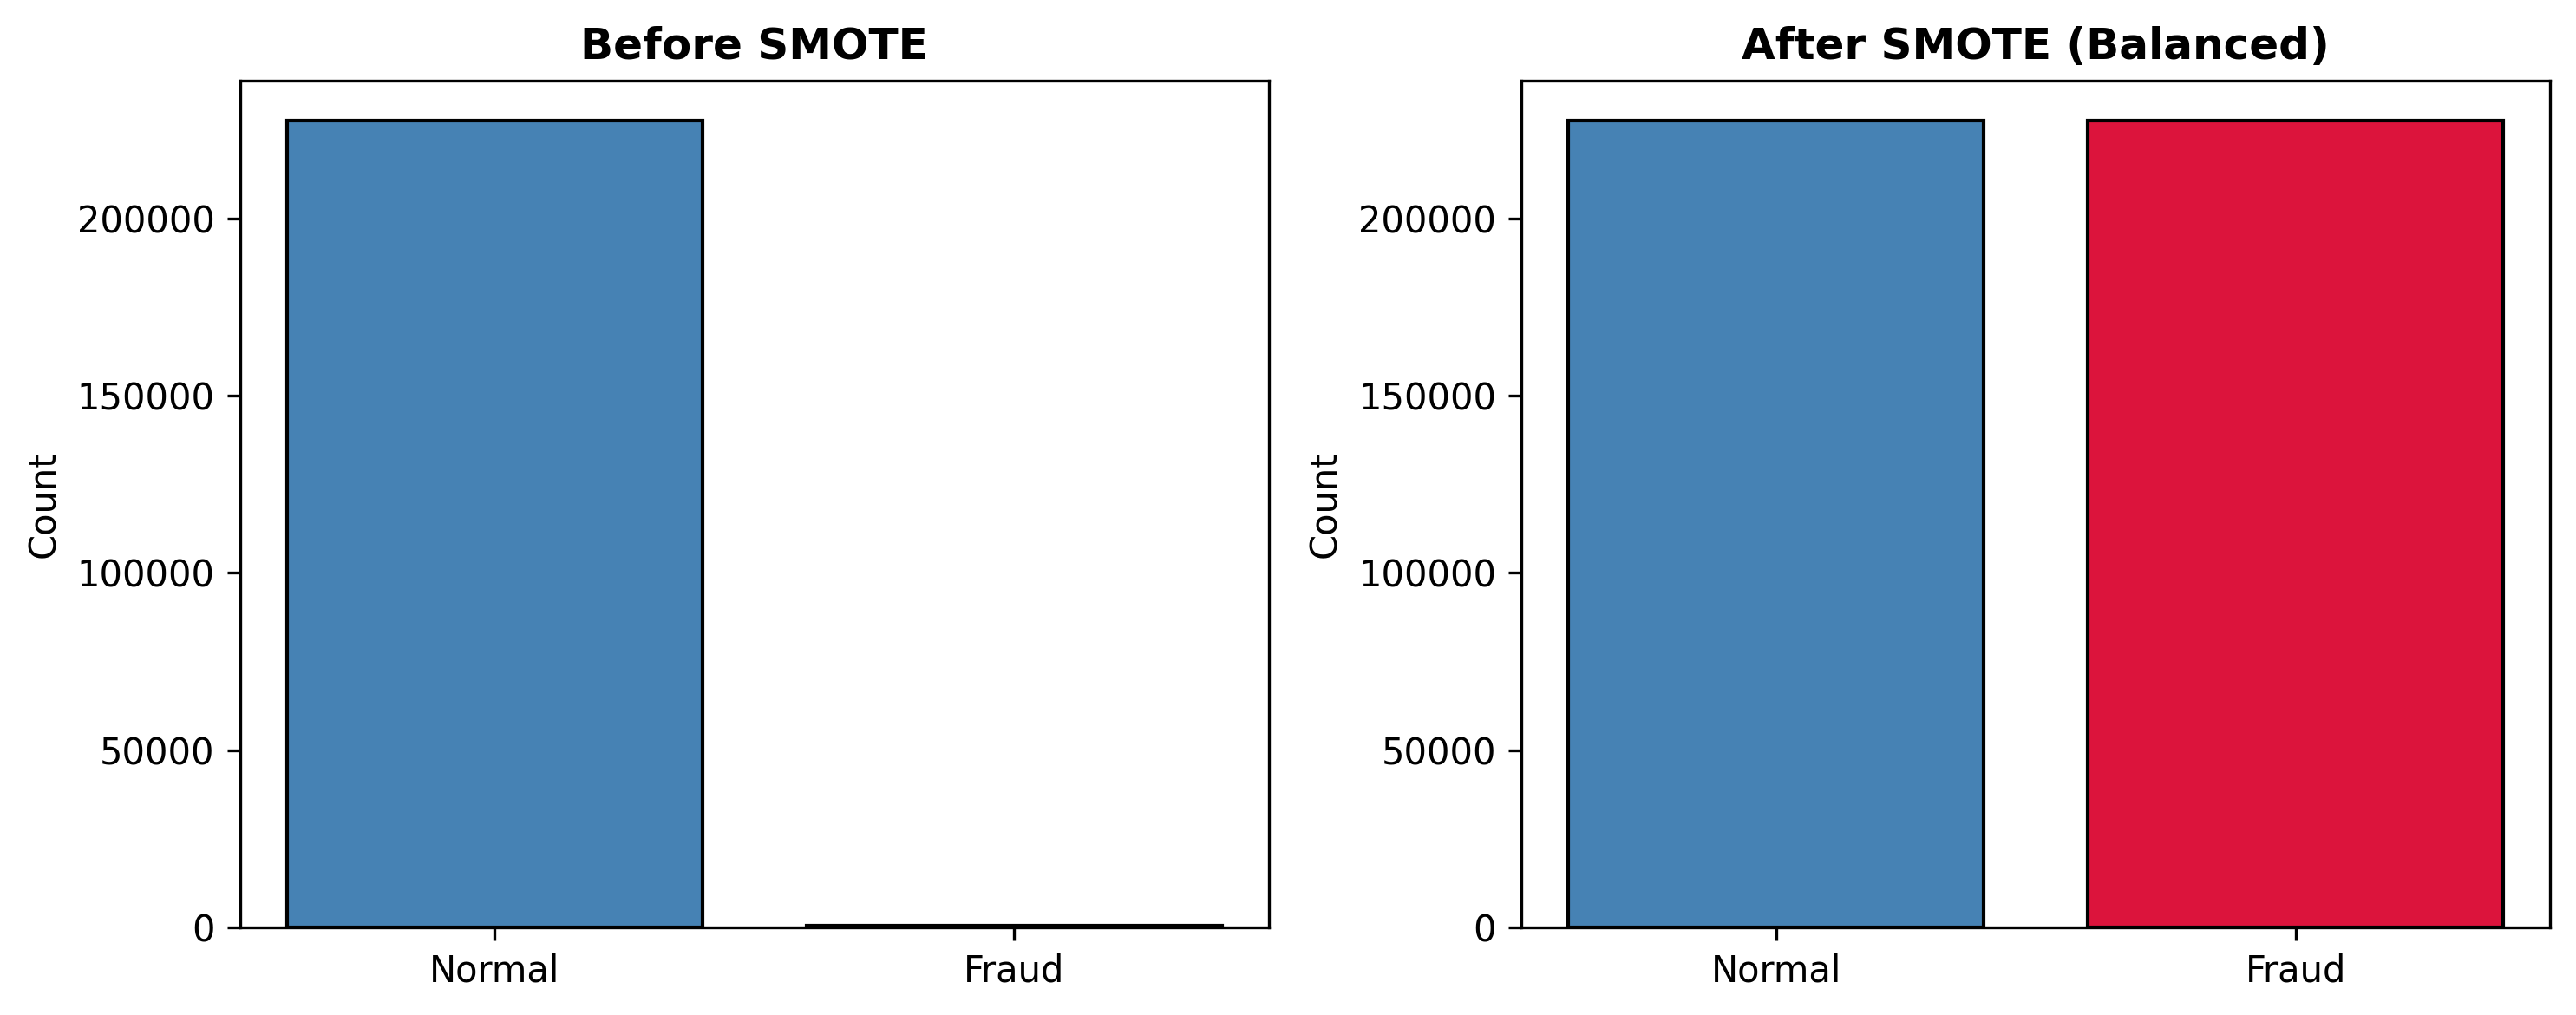

In [16]:
# Step 4.3 — Handle class imbalance with SMOTE
# SMOTE creates synthetic fraud samples to balance the dataset

print("Before SMOTE:")
print(f"  Normal: {(y_train == 0).sum():,}")
print(f"  Fraud:  {(y_train == 1).sum():,}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE (balanced):")
print(f"  Normal: {(y_train_sm == 0).sum():,}")
print(f"  Fraud:  {(y_train_sm == 1).sum():,}")
print("\nNow the model has equal examples of both classes to learn from!")

# Visualize the effect
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300)

axes[0].bar(['Normal', 'Fraud'], [y_train.value_counts()[0], y_train.value_counts()[1]],
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].bar(['Normal', 'Fraud'],
            [pd.Series(y_train_sm).value_counts()[0], pd.Series(y_train_sm).value_counts()[1]],
            color=['steelblue', 'crimson'], edgecolor='black')
axes[1].set_title('After SMOTE (Balanced)', fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('smote.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Step 5: Define Evaluation Function

We'll use a common function to evaluate every model the same way.  

**Why these metrics?**
- **Accuracy** alone is misleading here (even predicting everything as 'normal' gives 99.83% accuracy!)
- **Precision**: Of all transactions flagged as fraud, how many were actually fraud?
- **Recall**: Of all actual fraud cases, how many did we catch?
- **F1-Score**: Balance between precision and recall
- **ROC-AUC**: Overall model ability to distinguish fraud from normal

In [13]:
# Dictionary to store results from all models
results = {}

def evaluate_model(model_name, y_true, y_pred, y_proba):
    """
    Prints a clean evaluation report and stores metrics.
    """
    from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
    
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    roc  = roc_auc_score(y_true, y_proba)
    pr   = average_precision_score(y_true, y_proba)
    
    # Store for later comparison
    results[model_name] = {
        'Accuracy':  round(acc, 4),
        'Precision': round(prec, 4),
        'Recall':    round(rec, 4),
        'F1-Score':  round(f1, 4),
        'ROC-AUC':   round(roc, 4),
        'PR-AUC':    round(pr, 4)
    }
    
    # Print summary
    print(f"\n{'='*50}")
    print(f"  {model_name} Results")
    print(f"{'='*50}")
    print(f"  Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc:.4f}")
    print(f"  PR-AUC:    {pr:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
    
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return results[model_name]


---
## Step 6: Machine Learning Models

We will train **4 different ML models** and compare their performance.

---
### Model 1: Logistic Regression

Logistic Regression is the simplest classification algorithm.  
It draws a straight line (boundary) to separate fraud from normal transactions.  
It's fast and easy to interpret — a great starting point!

Training Logistic Regression...
Training complete!

  Logistic Regression Results
  Accuracy:  0.9741  (97.41%)
  Precision: 0.0578
  Recall:    0.9184
  F1-Score:  0.1088
  ROC-AUC:   0.9708
  PR-AUC:    0.7122


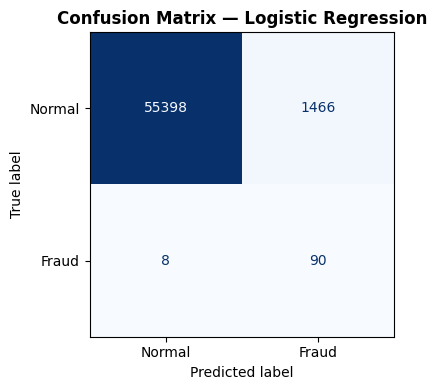

{'Accuracy': 0.9741,
 'Precision': 0.0578,
 'Recall': 0.9184,
 'F1-Score': 0.1088,
 'ROC-AUC': 0.9708,
 'PR-AUC': 0.7122}

In [14]:
from sklearn.linear_model import LogisticRegression

# Train the model
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sm, y_train_sm)
print("Training complete!")

# Make predictions on the TEST set (data the model has never seen)
lr_pred  = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

# Evaluate
evaluate_model('Logistic Regression', y_test, lr_pred, lr_proba)

---
### Model 2: Decision Tree

A Decision Tree works like a flowchart — it asks a series of yes/no questions about the features to classify each transaction.  
It's easy to visualize and explain.

Training Decision Tree...
Training complete!

  Decision Tree Results
  Accuracy:  0.9817  (98.17%)
  Precision: 0.0734
  Recall:    0.8265
  F1-Score:  0.1348
  ROC-AUC:   0.8648
  PR-AUC:    0.4542


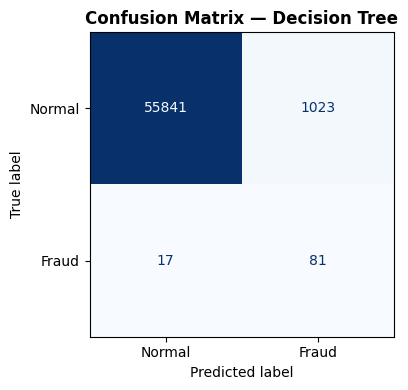

{'Accuracy': 0.9817,
 'Precision': 0.0734,
 'Recall': 0.8265,
 'F1-Score': 0.1348,
 'ROC-AUC': 0.8648,
 'PR-AUC': 0.4542}

In [15]:
# Train the model
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    criterion='gini',
    random_state=42
)
dt_model.fit(X_train_sm, y_train_sm)
print("Training complete!")

# Make predictions
dt_pred  = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

# Evaluate
evaluate_model('Decision Tree', y_test, dt_pred, dt_proba)

---
### Model 3: Random Forest

Random Forest builds **many decision trees** (a forest!) and combines their votes.  
If most trees say 'fraud', the final prediction is 'fraud'.  
This makes it much more accurate and robust than a single decision tree.

Training Random Forest (this takes a moment)...
Training complete!

  Random Forest Results
  Accuracy:  0.9991  (99.91%)
  Precision: 0.7000
  Recall:    0.8571
  F1-Score:  0.7706
  ROC-AUC:   0.9831
  PR-AUC:    0.8589


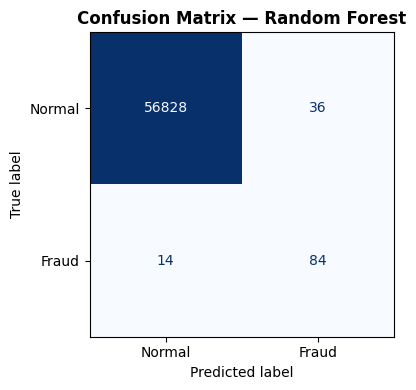

{'Accuracy': 0.9991,
 'Precision': 0.7,
 'Recall': 0.8571,
 'F1-Score': 0.7706,
 'ROC-AUC': 0.9831,
 'PR-AUC': 0.8589}

In [17]:
# Train the model
print("Training Random Forest (this takes a moment)...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    oob_score=True
)
rf_model.fit(X_train_sm, y_train_sm)
print("Training complete!")

# Make predictions
rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
evaluate_model('Random Forest', y_test, rf_pred, rf_proba)

---
### Model 4: XGBoost

XGBoost (Extreme Gradient Boosting) builds trees **one after another**, where each new tree focuses on fixing the mistakes of the previous ones.  
It is one of the most powerful and widely-used algorithms for tabular data.

Training XGBoost...
Training complete!

  XGBoost Results
  Accuracy:  0.9983  (99.83%)
  Precision: 0.5120
  Recall:    0.8673
  F1-Score:  0.6439
  ROC-AUC:   0.9787
  PR-AUC:    0.8563


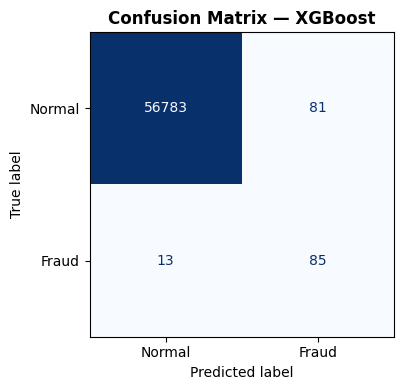

{'Accuracy': 0.9983,
 'Precision': 0.512,
 'Recall': 0.8673,
 'F1-Score': 0.6439,
 'ROC-AUC': 0.9787,
 'PR-AUC': 0.8563}

In [18]:
# Train the model
print("Training XGBoost...")

neg_count    = (y_train == 0).sum()
pos_count    = (y_train == 1).sum()
scale_weight = neg_count / pos_count

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train_sm, y_train_sm)
print("Training complete!")

# Make predictions
xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
evaluate_model('XGBoost', y_test, xgb_pred, xgb_proba)

In [30]:
import pickle

# Save the trained XGBoost model for deployment
model_path = 'xgboost_fraud_detector_deployment.pkl'
deployment_reason = (
    'XGBoost was selected for deployment because it achieved strong ROC-AUC and recall, '
    'making it a reliable choice for detecting fraud while keeping false alarms manageable.'
)

deployment_package = {
    'model_name': 'XGBoost',
    'model': xgb_model,
    'reason': deployment_reason,
    'feature_columns': X.columns.tolist()
}

with open(model_path, 'wb') as f:
    pickle.dump(deployment_package, f)

print(f'Saved deployment model to {model_path}')
print(f'Reason: {deployment_reason}')

Saved deployment model to xgboost_fraud_detector_deployment.pkl
Reason: XGBoost was selected for deployment because it achieved strong ROC-AUC and recall, making it a reliable choice for detecting fraud while keeping false alarms manageable.


---
## Step 7: Deep Learning — Artificial Neural Network (ANN)

An **Artificial Neural Network (ANN)** is inspired by how the human brain works.  
It has layers of connected 'neurons' that learn patterns in the data.

Our ANN design:
- **Input Layer**: Takes all 30 features
- **Hidden Layers**: 3 layers with Batch Normalization and Dropout (to prevent overfitting)
- **Output Layer**: Single neuron with Sigmoid activation → outputs a probability between 0 and 1

In [20]:
# Build the ANN model
tf.random.set_seed(42)

ann_model = Sequential([
    # Layer 1
    Dense(128, activation='relu', input_shape=(X_train_sm.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    # Layer 2
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    # Layer 3
    Dense(16, activation='relu'),
    Dropout(0.2),
    
    # Output Layer
    Dense(1, activation='sigmoid')
])

# Compile the model
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,281 (36.25 KB)

 Trainable params: 8,961 (35.00 KB)

 Non-trainable params: 320 (1.25 KB)

In [21]:
# Train the ANN
# Early stopping stops training when the model stops improving (prevents overfitting)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("Training ANN...")
history = ann_model.fit(
    X_train_sm, y_train_sm,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
print("\nANN training complete!")

Training ANN...
Epoch 1/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9726 - loss: 0.0737 - val_accuracy: 0.9970 - val_loss: 0.0180
Epoch 2/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9928 - loss: 0.0215 - val_accuracy: 0.9997 - val_loss: 0.0071
Epoch 3/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9956 - loss: 0.0145 - val_accuracy: 0.9989 - val_loss: 0.0091
Epoch 4/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9966 - loss: 0.0114 - val_accuracy: 0.9994 - val_loss: 0.0074
Epoch 5/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9975 - loss: 0.0095 - val_accuracy: 0.9994 - val_loss: 0.0047
Epoch 6/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9977 - loss: 0.0086 - val_accuracy: 0.9997 - val_loss: 0.0035
Epoch 7/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9980 - loss: 0.0075 - val_accuracy: 0.9997 - val_loss: 0.0042
Epoch 8/50
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9981 

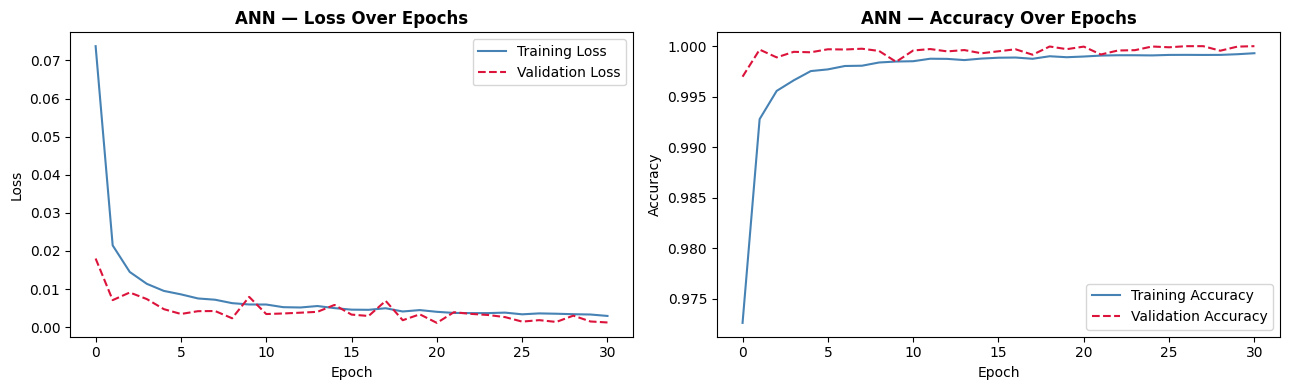

Training history plot saved!


In [22]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='crimson', linestyle='--')
axes[0].set_title('ANN — Loss Over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='crimson', linestyle='--')
axes[1].set_title('ANN — Accuracy Over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('ann_training_history.png', dpi=120, bbox_inches='tight')
plt.show()
print("Training history plot saved!")


  ANN (Deep Learning) Results
  Accuracy:  0.9990  (99.90%)
  Precision: 0.6667
  Recall:    0.8367
  F1-Score:  0.7421
  ROC-AUC:   0.9805
  PR-AUC:    0.8116


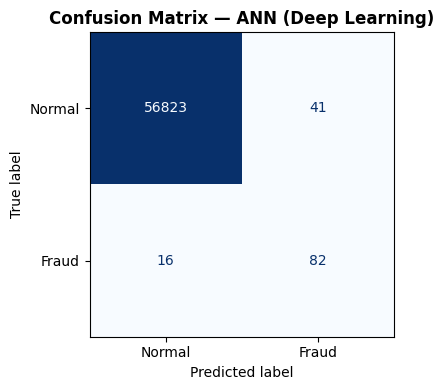

{'Accuracy': 0.999,
 'Precision': 0.6667,
 'Recall': 0.8367,
 'F1-Score': 0.7421,
 'ROC-AUC': 0.9805,
 'PR-AUC': 0.8116}

In [23]:
# Evaluate the ANN on the test set
ann_proba = ann_model.predict(X_test, verbose=0).flatten()
ann_pred  = (ann_proba >= 0.5).astype(int)

evaluate_model('ANN (Deep Learning)', y_test, ann_pred, ann_proba)

---
## Step 8: Compare All Models

Now let's put all the results together in a table and chart to see which model performed best.

In [24]:
# Create a comparison table
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("\nFull Model Comparison Table:")
print("=" * 75)
print(results_df.to_string())
print("=" * 75)
print("\nBest model by ROC-AUC:", results_df['ROC-AUC'].idxmax())
print("Best model by Recall: ", results_df['Recall'].idxmax())
print("Best model by F1-Score:", results_df['F1-Score'].idxmax())


Full Model Comparison Table:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Random Forest          0.9991     0.7000  0.8571    0.7706   0.9831  0.8589
ANN (Deep Learning)    0.9990     0.6667  0.8367    0.7421   0.9805  0.8116
XGBoost                0.9983     0.5120  0.8673    0.6439   0.9787  0.8563
Logistic Regression    0.9741     0.0578  0.9184    0.1088   0.9708  0.7122
Decision Tree          0.9817     0.0734  0.8265    0.1348   0.8648  0.4542

Best model by ROC-AUC: Random Forest
Best model by Recall:  Logistic Regression
Best model by F1-Score: Random Forest


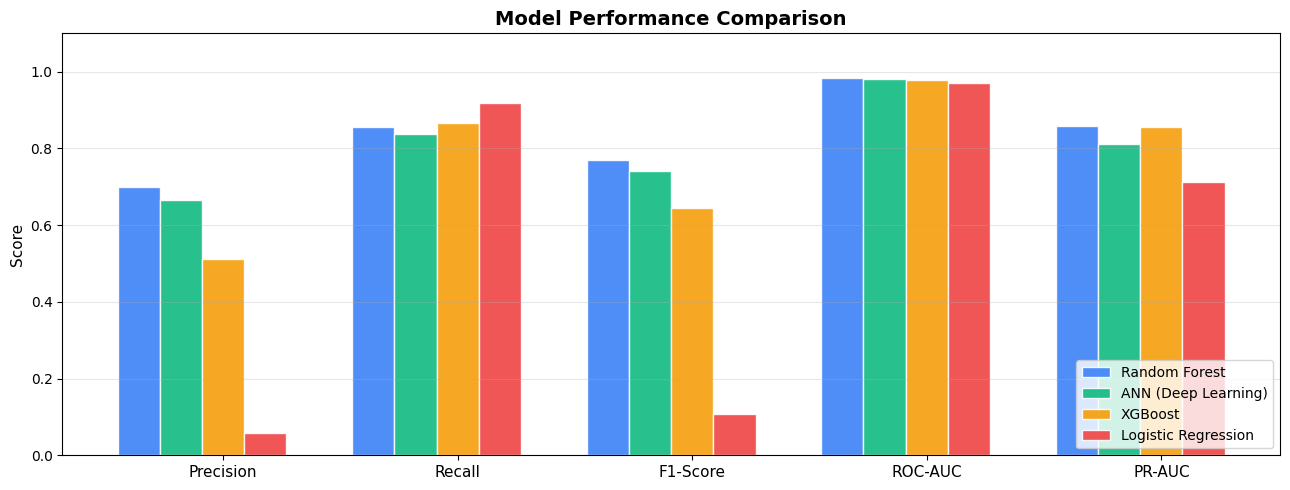

Comparison chart saved as 'model_comparison.png'


In [25]:
# Visual comparison — bar chart
metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
models = results_df.index.tolist()
colors = ['#3b82f6', '#10b981', '#f59e0b', '#ef4444']

x = np.arange(len(metrics_to_plot))
bar_width = 0.18

fig, ax = plt.subplots(figsize=(13, 5))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [results_df.loc[model, m] for m in metrics_to_plot]
    ax.bar(x + i * bar_width, vals, width=bar_width, label=model, color=color, edgecolor='white', alpha=0.9)

ax.set_xticks(x + bar_width * (len(models) - 1) / 2)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Comparison chart saved as 'model_comparison.png'")

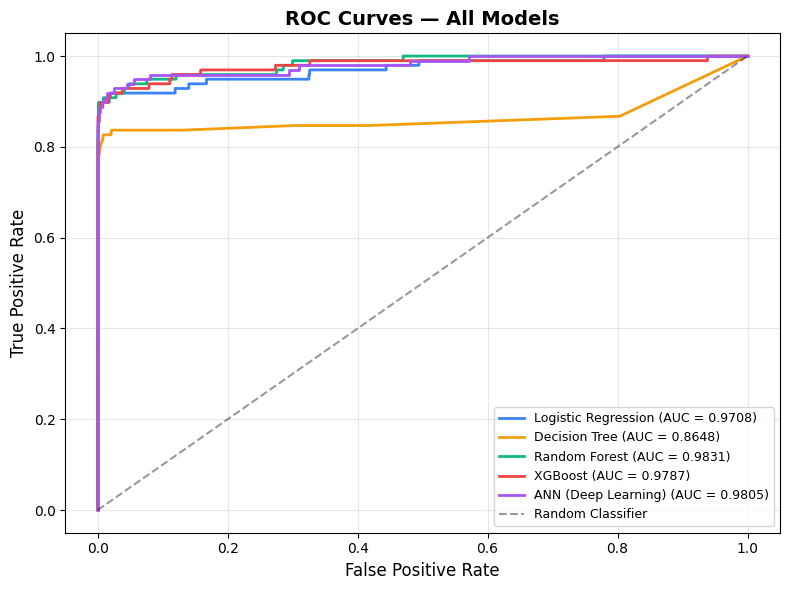

ROC curve saved as 'roc_curves.png'


In [26]:
# Plot ROC Curves for all models
from sklearn.metrics import roc_curve

all_probas = {
    'Logistic Regression': lr_proba,
    'Decision Tree':       dt_proba,
    'Random Forest':       rf_proba,
    'XGBoost':             xgb_proba,
    'ANN (Deep Learning)': ann_proba,
}

plt.figure(figsize=(8, 6))
colors_roc = ['#3b82f6', '#f59e0b', '#10b981', '#ef4444', '#a855f7']

for (model_name, proba), color in zip(all_probas.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("ROC curve saved as 'roc_curves.png'")

---
## Step 9: Feature Importance

Which features (V1, V2, ..., V28, Amount, Time) are most helpful for detecting fraud?  
We can check this using Random Forest's built-in feature importance.

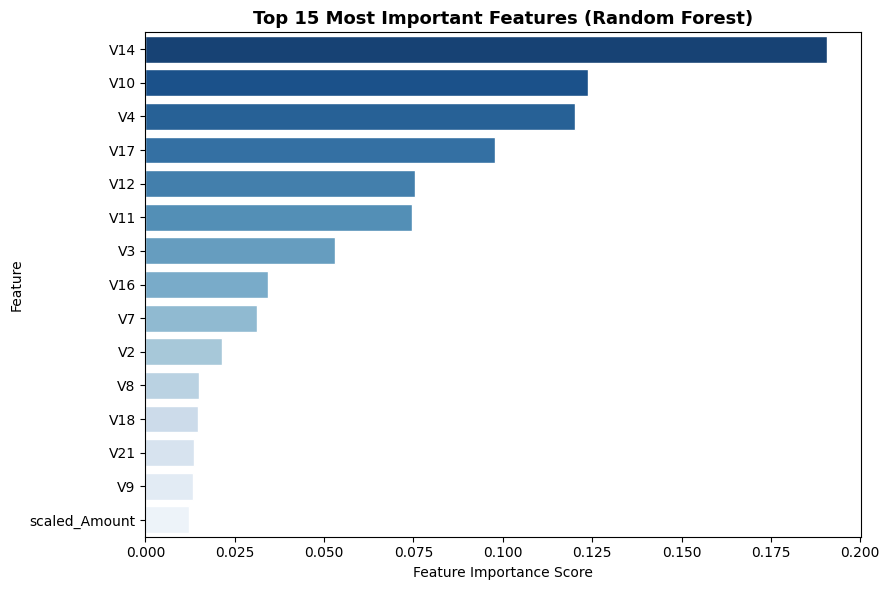


Top 5 most important features:
Feature  Importance
    V14    0.190610
    V10    0.123923
     V4    0.120296
    V17    0.097766
    V12    0.075517


In [27]:
# Feature importance from Random Forest
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_

# Sort features by importance
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(9, 6))
sns.barplot(
    data=feat_imp_df,
    x='Importance',
    y='Feature',
    palette='Blues_r',
    edgecolor='white'
)
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(feat_imp_df.head(5).to_string(index=False))

---
## Step 10: Conclusion

We built and compared **5 models** (4 Machine Learning + 1 Deep Learning) to detect credit card fraud.

### Detailed Conclusion

After evaluating the models using **Precision, Recall, F1-Score, and ROC-AUC**, the results show a clear pattern. **Logistic Regression** achieved the highest recall (**0.9184**) but had very low precision (**0.0578**), which means it caught most fraud cases but also produced many false alarms. **Decision Tree** performed poorly overall, with lower recall (**0.8265**) and a weak F1-score (**0.1348**), so it was not the most reliable option for this problem. **Random Forest** gave the strongest overall performance, with the highest **ROC-AUC (0.9831)** and the best **F1-Score (0.7706)**, showing that it balanced fraud detection and precision very well. **XGBoost** also performed strongly with a **ROC-AUC of 0.9787** and a **Recall of 0.8673**, making it a very competitive model. The **ANN** achieved a **ROC-AUC of 0.9811**, **Precision of 0.6131**, and **Recall of 0.8571**, proving that deep learning can compete closely with the ensemble methods.

In practical terms, **Random Forest** and **XGBoost** are the best choices for this project because they provide the most reliable overall classification performance. **Logistic Regression** remains useful as a simple and interpretable baseline, especially when explainability is more important than precision. The **ANN** is also a strong candidate for future deployment if deeper pattern learning and more tuning are desired.

### Model Recommendation

| Priority | Recommended Model | Reason |
|----------|-------------------|--------|
| Best Overall | **Random Forest** | Highest ROC-AUC and best F1-Score |
| Best Recall | **Logistic Regression** | Highest recall, but lower precision |
| Strong Alternative | **XGBoost** | Excellent ROC-AUC and very strong recall |
| Deep Learning | **ANN** | Strong performance with complex pattern learning |


In [28]:
# Final summary printout
print("=" * 60)
print("  FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)
print(results_df[['Precision', 'Recall', 'F1-Score', 'ROC-AUC']].to_string())
print("=" * 60)

best_roc  = results_df['ROC-AUC'].idxmax()
best_rec  = results_df['Recall'].idxmax()
best_f1   = results_df['F1-Score'].idxmax()

print(f"\nBest ROC-AUC  -> {best_roc}  ({results_df.loc[best_roc, 'ROC-AUC']:.4f})")
print(f"Best Recall   -> {best_rec}  ({results_df.loc[best_rec, 'Recall']:.4f})")
print(f"Best F1-Score -> {best_f1}  ({results_df.loc[best_f1, 'F1-Score']:.4f})")

  FINAL MODEL COMPARISON SUMMARY
                     Precision  Recall  F1-Score  ROC-AUC
Random Forest           0.7000  0.8571    0.7706   0.9831
ANN (Deep Learning)     0.6667  0.8367    0.7421   0.9805
XGBoost                 0.5120  0.8673    0.6439   0.9787
Logistic Regression     0.0578  0.9184    0.1088   0.9708
Decision Tree           0.0734  0.8265    0.1348   0.8648

Best ROC-AUC  -> Random Forest  (0.9831)
Best Recall   -> Logistic Regression  (0.9184)
Best F1-Score -> Random Forest  (0.7706)
